# Линейная регрессия на синтетических данных (продолжение)

Рассматриваются следующие вопросы:
- Порождение новых признаков
- Гиперпараметры модели
- Проблема переобучения модели
- Кросс-валидация, тестовая и тренировочные выборки
- Масштабирование данных (стандартизация) 

### Полезные ссылки:
- <a href="https://numpy.org/">Numpy documentation</a><br />
- <a href="https://pandas.pydata.org/">Pandas documentation</a><br />
- <a href="https://matplotlib.org/">Matplotlib documentation</a><br />
- <a href="https://scikit-learn.org/stable/">sklearn documentation</a><br />

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Генерация данных 

Порождаем синтетические данные с зависимость y от x в форме многочлена 3-й степени. Для этого используем модель препроцессинга [PolynomialFeatures](https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) библиотеки sklearn. 

X shape:  (30,)
X_poly shape:  (30, 4)


,0
0,6.819224
1,6.383219
2,-8.200112
3,0.847850
4,8.286111


,0,1,2,3
0,1.0,6.819224,46.501822,317.106362
1,1.0,6.383219,40.745481,260.087317
2,1.0,-8.200112,67.241838,-551.390603
3,1.0,0.847850,0.718850,0.609477
4,1.0,8.286111,68.659636,568.921361


(-10.0, 10.0)

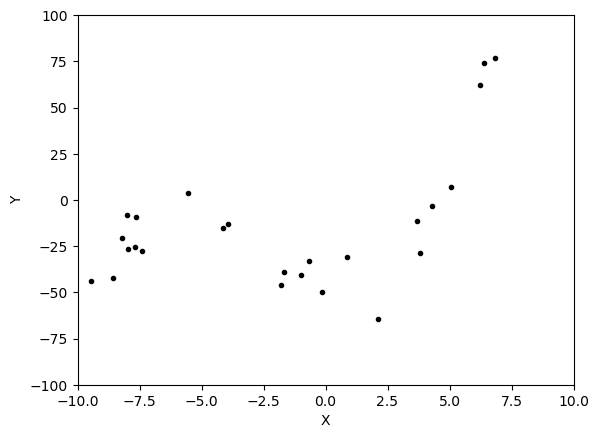

In [13]:
def generate_data (sample_size = 40):
    
    #true_degee = 4; true_theta = [0, -2.5, -1.9, -0.019, 0.021]
    true_degee = 3; true_theta = [-50, -4, 1.9, 0.25]

    
    X = np.random.rand(sample_size) * 20 - 10
    #X = np.linspace(-10, 10, sample_size)
    
    poly = PolynomialFeatures(true_degee)
    X_poly = poly.fit_transform(X.reshape(-1, 1))
    print('X shape: ', X.shape)
    print('X_poly shape: ', X_poly.shape)

    display(pd.DataFrame (X).head())
    display(pd.DataFrame (X_poly).head())

    Y = np.dot(X_poly, true_theta) + np.random.randn(sample_size) * 10 #+ np.random.randn(sample_size) * np.sqrt (np.abs(X)) * 2
    return X, Y

X, Y = generate_data (30)

plt.figure()
plt.plot(X, Y, '.k')
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim([-100, 100])
plt.xlim([-10, 10])


## Создаем новый класс моделей машинного обучения - полиномиальную регрессию

Данная модель объединяет модель линейной регресии [LinearRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html), модель порождения полиномиальных признаков   [PolynomialFeatures](https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) и, опционально, произвольную модель масштабирования данных.  

Модель имеет два **гиперпараметра**:
- Степень полинома
- Модель масштабирования данных (по умолчанию отсутствует)

In [ ]:
class PolynomialRegression:
    def __init__(self, degree = 1, scaler = None):
        self.degree = degree
        self.regressor = LinearRegression()
        self.scaler = scaler () if scaler is not None else None
        
    def fit(self, X, Y):
        self.poly = PolynomialFeatures(self.degree)
        X_poly = self.poly.fit_transform(X.reshape(-1, 1))
        
        if self.scaler is not None:
            X_poly = self.scaler.fit_transform(X_poly)
        #display(pd.DataFrame(X_poly).describe())
        self.regressor.fit(X_poly, Y)
        
    def predict(self, X):
        X_poly = self.poly.fit_transform(X.reshape(-1, 1))
        if self.scaler is not None:
            X_poly = self.scaler.transform(X_poly)       
        return self.regressor.predict(X_poly)

## Обучение модели с вручную задаваемыми гиперпараметрами 

Изучаем, как ведет себя модель с различными гиперпараметрами (меняем степень полинома и модель масштабирования данных) и при различном размере набора данных.

In [6]:
Y.reshape((1,-1)).shape

(1, 200)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,-1.850372e-17,5.181041e-17,-3.423188e-17,-9.251859e-18,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-1.740679e+00,-2.691205e-01,-1.592791e+00,-2.561291e-01,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-1.399467e-01,-2.691205e-01,-1.429291e-01,-2.561291e-01,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-1.331633e-01,-2.688982e-01,-1.391854e-01,-2.560395e-01,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-1.329691e-01,-2.307182e-01,-1.391092e-01,-2.314774e-01,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.113210e+00,5.148614e+00,5.170574e+00,5.197756e+00,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


RMSE =  0.0017971333188680548


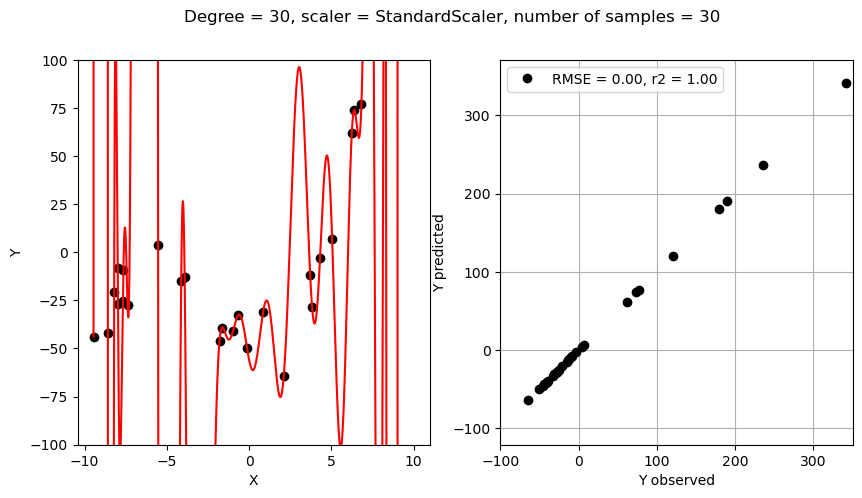

In [24]:
def evaluate_model (model, X, Y):
    model.fit(X, Y)
    Y_predicted = model.predict(X)
    rmse = np.sqrt(mean_squared_error(Y, Y_predicted))
    r2 = r2_score(Y, Y_predicted)
    
    print ('RMSE = ', rmse)
    X_smooth = np.linspace(X.min(), X.max(), 10000)
    Y_predicted_smooth = model.predict(X_smooth)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,2)
    plt.plot (Y, Y_predicted, 'ok', label = 'RMSE = %.2f, r2 = %.2f'%(rmse, r2))
    plt.axis('equal')
    plt.grid()
    plt.ylim([-100, 350])
    plt.xlim([-100, 350])
    plt.xlabel('Y observed')
    plt.ylabel('Y predicted')
    plt.legend(loc='upper left')

    plt.subplot(1,2,1)
    plt.plot(X, Y, 'ok')
    plt.ylim([-100, 100])
    plt.plot(X_smooth, Y_predicted_smooth, '-r')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.suptitle('Degree = %d, scaler = %s, number of samples = %d'%(model.degree, model.scaler.__class__.__name__, Y.shape[0]))

model = PolynomialRegression(30, scaler=StandardScaler) 

evaluate_model (model, X, Y)


## Оптимизация ~~гиперпараметров~~ гиперпараметра методом конечного перебора

Подойдем к проблеме оптимизации гиперпараметра (степени полинома) формально и попробуем найти оптимальное значение. 

,0
count,30.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


,0,1
count,30.0,3.000000e+01
mean,0.0,-1.480297e-17
std,0.0,1.017095e+00
min,0.0,-1.501475e+00
25%,0.0,-1.097499e+00
50%,0.0,-5.652706e-02
75%,0.0,9.550168e-01
max,0.0,1.603715e+00


,0,1,2
count,30.0,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17
std,0.0,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00
25%,0.0,-1.097499e+00,-8.434422e-01
50%,0.0,-5.652706e-02,1.885158e-02
75%,0.0,9.550168e-01,8.176769e-01
max,0.0,1.603715e+00,2.025966e+00


,0,1,2,3
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00


,0,1,2,3,4
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00


...

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,-1.850372e-17,5.181041e-17,-3.423188e-17,-9.251859e-18,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-1.740679e+00,-2.691205e-01,-1.592791e+00,-2.561291e-01,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-1.399467e-01,-2.691205e-01,-1.429291e-01,-2.561291e-01,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-1.331633e-01,-2.688982e-01,-1.391854e-01,-2.560395e-01,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-1.329691e-01,-2.307182e-01,-1.391092e-01,-2.314774e-01,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.113210e+00,5.148614e+00,5.170574e+00,5.197756e+00,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,5.181041e-17,-3.423188e-17,-9.251859e-18,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17,2.868076e-17
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-2.691205e-01,-1.592791e+00,-2.561291e-01,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01,-1.107814e+00
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-2.691205e-01,-1.429291e-01,-2.561291e-01,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01,-1.562660e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-2.688982e-01,-1.391854e-01,-2.560395e-01,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01,-1.559255e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-2.307182e-01,-1.391092e-01,-2.314774e-01,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01,-1.559237e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.148614e+00,5.170574e+00,5.197756e+00,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00,5.300540e+00


,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,-3.423188e-17,-9.251859e-18,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17,2.868076e-17,-9.251859e-19
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-1.592791e+00,-2.561291e-01,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01,-1.107814e+00,-2.244027e-01
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-1.429291e-01,-2.561291e-01,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01,-1.562660e-01,-2.244027e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-1.391854e-01,-2.560395e-01,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01,-1.559255e-01,-2.244003e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-1.391092e-01,-2.314774e-01,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01,-1.559237e-01,-2.202658e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.170574e+00,5.197756e+00,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00,5.300540e+00,5.310569e+00


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,-9.251859e-18,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17,2.868076e-17,-9.251859e-19,-5.921189e-17
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-2.561291e-01,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01,-1.107814e+00,-2.244027e-01,-1.012603e+00
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-2.561291e-01,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01,-1.562660e-01,-2.244027e-01,-1.591321e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-2.560395e-01,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01,-1.559255e-01,-2.244003e-01,-1.589457e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-2.314774e-01,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01,-1.559237e-01,-2.202658e-01,-1.589450e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.197756e+00,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00,5.300540e+00,5.310569e+00,5.317928e+00


,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
count,30.0,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,...,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01
mean,0.0,-1.480297e-17,-7.031412e-17,-1.942890e-17,2.035409e-16,1.457168e-17,1.739349e-16,3.654484e-17,3.330669e-17,3.515706e-17,...,-2.312965e-17,5.551115e-18,-2.683039e-17,-3.700743e-17,-2.590520e-17,-1.017704e-17,2.868076e-17,-9.251859e-19,-5.921189e-17,-6.476301e-18
std,0.0,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,...,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00,1.017095e+00
min,0.0,-1.501475e+00,-1.308184e+00,-2.022329e+00,-9.255529e-01,-2.354399e+00,-7.285125e-01,-2.525584e+00,-5.928276e-01,-2.557871e+00,...,-1.455257e+00,-2.457189e-01,-1.328658e+00,-2.372443e-01,-1.212972e+00,-2.302483e-01,-1.107814e+00,-2.244027e-01,-1.012603e+00,-2.194674e-01
25%,0.0,-1.097499e+00,-8.434422e-01,-8.137785e-01,-8.516380e-01,-5.508742e-01,-7.169342e-01,-3.701787e-01,-5.910776e-01,-2.582282e-01,...,-1.463480e-01,-2.457189e-01,-1.498180e-01,-2.372443e-01,-1.531517e-01,-2.302483e-01,-1.562660e-01,-2.244027e-01,-1.591321e-01,-2.194674e-01
50%,0.0,-5.652706e-02,1.885158e-02,1.817580e-02,-3.239014e-01,4.880903e-03,-4.597202e-01,-2.156494e-02,-4.769908e-01,-4.891582e-02,...,-1.442871e-01,-2.456828e-01,-1.486856e-01,-2.372298e-01,-1.525304e-01,-2.302425e-01,-1.559255e-01,-2.244003e-01,-1.589457e-01,-2.194665e-01
75%,0.0,9.550168e-01,8.176769e-01,5.352115e-01,6.171480e-01,2.512749e-01,3.742051e-01,8.815022e-02,1.670909e-01,-2.242870e-03,...,-1.442572e-01,-2.299173e-01,-1.486739e-01,-2.271272e-01,-1.525258e-01,-2.237767e-01,-1.559237e-01,-2.202658e-01,-1.589450e-01,-2.168245e-01
max,0.0,1.603715e+00,2.025966e+00,2.435144e+00,2.868499e+00,3.131613e+00,3.524482e+00,3.692695e+00,4.003441e+00,4.116437e+00,...,5.215470e+00,5.236500e+00,5.250755e+00,5.267118e+00,5.278568e+00,5.291356e+00,5.300540e+00,5.310569e+00,5.317928e+00,5.325814e+00


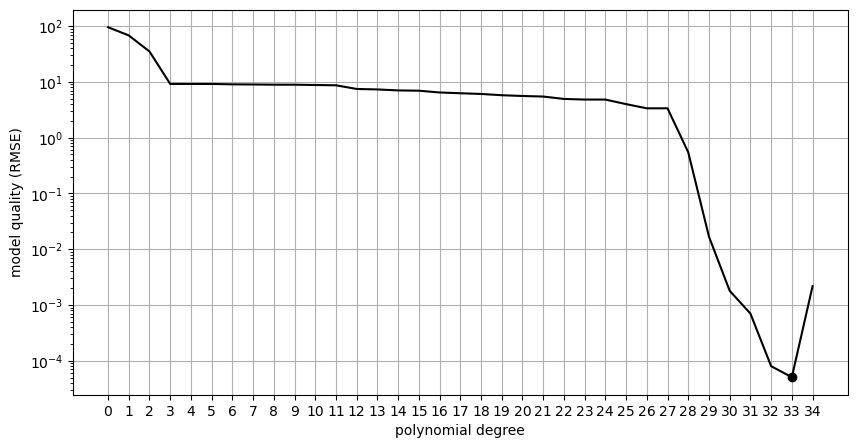

In [25]:
model_quality = []

degrees = range(0, 35)
for degree in degrees:
    model = PolynomialRegression(degree, scaler = StandardScaler)
    model.fit(X, Y)
    Y_predicted = model.predict(X)
    model_quality.append (np.sqrt(mean_squared_error(Y, Y_predicted)))

best_idx  = np.argmin(model_quality)

plt.figure(figsize=(10,5))
plt.plot (degrees, model_quality, '-k')
plt.plot (degrees[best_idx], model_quality[best_idx], 'ok')
plt.grid()
plt.xlabel('polynomial degree')
plt.ylabel('model quality (RMSE)')

plt.yscale('log')
_ = plt.xticks(degrees)

## Оптимизация ~~гиперпараметров~~ гиперпараметра методом конечного перебора - **теперь с разделением на тренировочную и тестовую выборки**

In [ ]:

rmse_test = []
rmse_train = []

degrees = range(1, 31)

for degree in degrees:
    model = PolynomialRegression(degree, scaler = StandardScaler)
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25)
    model.fit(x_train, y_train)
    y_test_predicted = model.predict(x_test)
    y_train_predicted = model.predict(x_train)
    
    rmse_test.append (np.sqrt(mean_squared_error(y_test, y_test_predicted)))
    rmse_train.append (np.sqrt(mean_squared_error(y_train, y_train_predicted)))

best_idx_test  = np.argmin(rmse_test)
best_idx_train = np.argmin(rmse_train)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot (degrees, rmse_train, '-k', label = 'train')
plt.plot (degrees, rmse_test, '-r', label = 'test')
plt.plot (degrees[best_idx_train], rmse_train[best_idx_train], 'ok')
plt.plot (degrees[best_idx_test], rmse_test[best_idx_test], 'or')

plt.grid()
plt.legend()
plt.xlabel('polynomial degree')
plt.ylabel('model quality (RMSE)')

plt.yscale('log')
_ = plt.xticks(degrees)


